In [25]:
import graph_tool.all as gt
import matplotlib.pyplot as plt

## Problem 1

In [23]:
g = gt.collection.ns["polblogs"]
g.set_directed(False)

gt.remove_parallel_edges(g)
gt.remove_self_loops(g)
print(g)

g = gt.extract_largest_component(g, directed=False, prune=True)
print(g)

<Graph object, undirected, with 1490 vertices and 16715 edges, 4 internal vertex properties, 6 internal graph properties, at 0x7907535779d0>
<Graph object, undirected, with 1222 vertices and 16714 edges, 4 internal vertex properties, 6 internal graph properties, at 0x79075042f050>


In [59]:
deg_corr_state = gt.minimize_blockmodel_dl(g, state_args={"B": 2, "deg_corr": True})
print(f"Degree-corrected entropy: {deg_corr_state.entropy()}")

non_deg_corr_state = gt.minimize_blockmodel_dl(g, state_args={"B": 2, "deg_corr": False})
print(f"Non-degree-corrected entropy: {deg_corr_state.entropy()}")

pos = gt.sfdp_layout(g)

Degree-corrected entropy: 51282.211271729684
Non-degree-corrected entropy: 51282.211271729684


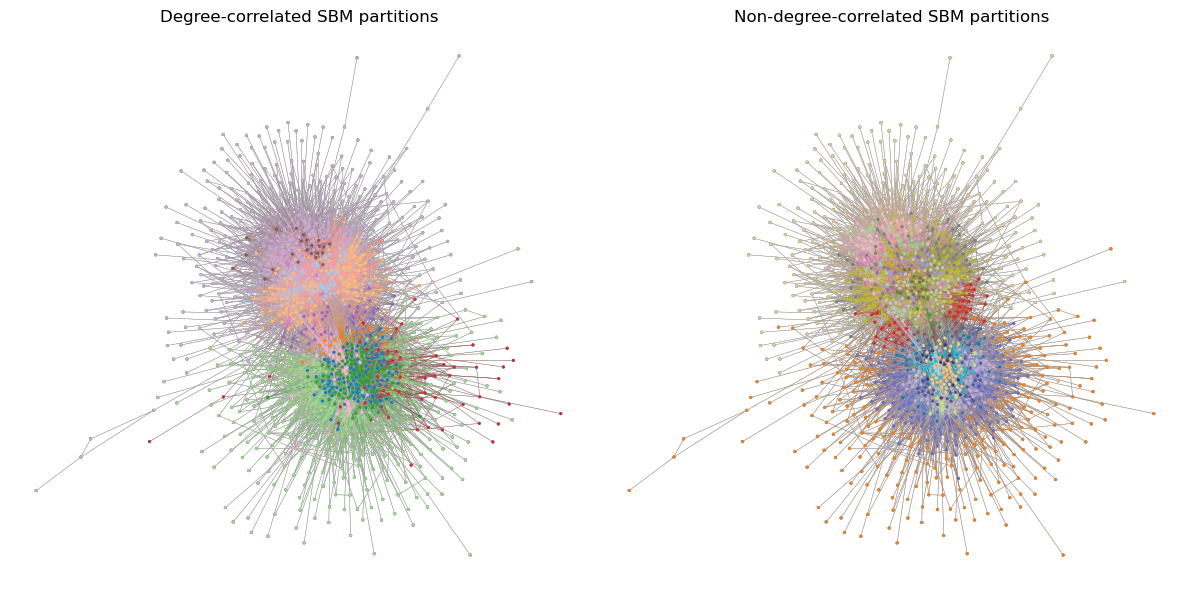

In [60]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

a = deg_corr_state.draw(pos=pos, mplfig=ax[0])
ax[0].set_axis_off()
ax[0].set_title("Degree-correlated SBM partitions")

a = non_deg_corr_state.draw(pos=pos, mplfig=ax[1])
ax[1].set_axis_off()
ax[1].set_title("Non-degree-correlated SBM partitions")

plt.tight_layout()
plt.savefig("figures/1_deg_corr_sbm_partitions.png")